In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"] = "true"

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model = 'deepseek-r1-distill-llama-70b',
    temperature=0.0
)

In [3]:
llm.invoke('hi')

AIMessage(content='<think>\n\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 4, 'total_tokens': 20, 'completion_time': 0.085387168, 'prompt_time': 7.485e-05, 'queue_time': 0.05235709, 'total_time': 0.085462018}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_76307ac09b', 'finish_reason': 'stop', 'logprobs': None}, id='run--e2e02741-bf24-47fe-b7d5-433da02daca8-0', usage_metadata={'input_tokens': 4, 'output_tokens': 16, 'total_tokens': 20})

In [4]:
from langchain_experimental.utilities import PythonREPL
from langchain_tavily import TavilySearch

In [5]:
search_tool = TavilySearch()

In [6]:
search_tool.invoke("what is latest news on crude oil?")

{'query': 'what is latest news on crude oil?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.investing.com/commodities/crude-oil-news',
   'title': 'Crude Oil WTI Futures News - Investing.com',
   'content': 'The latest news and headlines regarding Crude Oil WTI Futures - prices, market changes and more.',
   'score': 0.7089592,
   'raw_content': None},
  {'url': 'https://www.fxstreet.com/markets/commodities/energy/oil',
   'title': 'Oil News and Forecast - FXStreet',
   'content': 'Latest Oil News · Brent creeps back above $70/bbl – ING. By FXStreet Insights Team | 08:26 GMT · WTI rises above $67.00 due to rising supply concerns, US tariffs',
   'score': 0.67321366,
   'raw_content': None},
  {'url': 'https://www.cnbc.com/oil/',
   'title': 'Crude Oil Prices Today and Oil Market News - CNBC',
   'content': "Follow today's crude oil price moves and key news stories driving oil price actions, as well as developments in the broader energy

In [7]:
repl = PythonREPL()

In [8]:
code = """
x = 5
y = x * 2
print(y)
"""

In [9]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'10\n'

In [10]:
from typing import Annotated
from langchain_core.tools import tool

In [11]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
C:\Users\Bapan Bairagya\AppData\Local\Temp\ipykernel_1812\2173611335.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\Bapan Bairagya\AppData\Local\Temp\ipykernel_1812\2173611335.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [12]:

response = python_repl_tool.invoke("x=10\ny=x+10\nprint(y)")
print(response)

Successfully executed:
\`\`\`python
x=10
y=x+10
print(y)
\`\`\`
Stdout: 20


If you have completed all tasks, respond with FINAL ANSWER.


In [13]:
print(python_repl_tool.invoke(code))

Successfully executed:
\`\`\`python

x = 5
y = x * 2
print(y)

\`\`\`
Stdout: 10


If you have completed all tasks, respond with FINAL ANSWER.


##### **Let's moving forward to create agents**
##### We have two sub-agents

*   RESEARCHER- internet
*   CODE executor

In [14]:
members = ["researcher","coder"]
members

['researcher', 'coder']

In [15]:
options = members + ["FINISH"]
options

['researcher', 'coder', 'FINISH']

In [16]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, StateGraph, START, END

In [17]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

class State(MessagesState):
    next:str

In [18]:
system_prompt = f"""
You are a supervisor responsible for managing a conversation between the following workers: {members}.  
Given the user's request below, decide which worker should act next.  
Each worker will perform a task and respond with their result and status.  
Once all tasks are completed, respond with "FINISH".
"""
print(system_prompt)


You are a supervisor responsible for managing a conversation between the following workers: ['researcher', 'coder'].  
Given the user's request below, decide which worker should act next.  
Each worker will perform a task and respond with their result and status.  
Once all tasks are completed, respond with "FINISH".



In [19]:

state = {"messages": ["hi"], "next": "research_agent"}

messages = [{"role": "system", "content": system_prompt},] + state["messages"]

print(messages)

[{'role': 'system', 'content': '\nYou are a supervisor responsible for managing a conversation between the following workers: [\'researcher\', \'coder\'].  \nGiven the user\'s request below, decide which worker should act next.  \nEach worker will perform a task and respond with their result and status.  \nOnce all tasks are completed, respond with "FINISH".\n'}, 'hi']


[{'role': 'system', 'content': '\nYou are a supervisor responsible for managing a conversation between the following workers: [\'researcher\', \'coder\'].  \nGiven the user\'s request below, decide which worker should act next.  \nEach worker will perform a task and respond with their result and status.  \nOnce all tasks are completed, respond with "FINISH".\n'}, 'hi']

In [20]:
llm_with_structure_output = llm.with_structured_output(Router)
llm_with_structure_output.invoke(messages)

{'next': 'researcher'}

In [ ]:
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage

In [22]:
def supervisor(state:State) -> Command[Literal['researcher', 'coder', '__end__']]:
    
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    llm_with_structure_output = llm.with_structured_output(Router)
    
    response = llm_with_structure_output.invoke(messages)
    
    goto = response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH":
        goto = END
    
    return Command(goto=goto, update={"next":goto})


def research_agent(state: State) -> Command[Literal["supervisor"]]:
    
    research_agent = create_react_agent(
        llm, 
        tools=[search_tool], 
        prompt="You are a researcher. DO NOT do any math."
    )
    
    result = research_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )


def coder_agent(state:State) -> Command[Literal['supervisor']]:
    code_agent = create_react_agent(
        llm,
        tools=[python_repl_tool], 
        prompt="You are a coder. DO NOT do any research."
    )
    
    result = code_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )

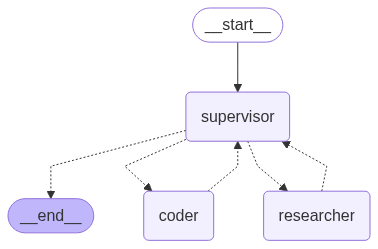

In [23]:
graph = StateGraph(State)

graph.add_node("supervisor", supervisor)

graph.add_node("researcher", research_agent)
graph.add_node("coder", coder_agent)

graph.add_edge(START, "supervisor")

app = graph.compile()
app

In [ ]:
# Test the system
print("Testing the multi-agent system...")
print("=" * 50)

events = app.stream(
    {
        "messages": [("user","write an efficient python code to get the prime number.")]
    },
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

Testing the multi-agent system...
================================ Human Message =================================

write an efficient python code to get the prime number.
**********BELOW IS MY GOTO***************
coder
================================ Human Message =================================

write an efficient python code to get the prime number.
================================ Human Message =================================
Name: coder

Here's an efficient Python code to find prime numbers using both the Sieve of Eratosthenes and an optimized primality test:

```python
def is_prime(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    w = 2
    while i * i <= n:
        if n % i == 0:
            return False
        i += w
        w = 6 - w
    return True

def get_primes(limit):
    sieve = [True] * (limit + 1)
    sieve[0] = sieve[1] = False
    for num in range(2, int(limit ** 0.5) +